In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Shape:", df.shape)

df.info()

df.describe().T

Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


/tmp/ipykernel_569/2098547663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


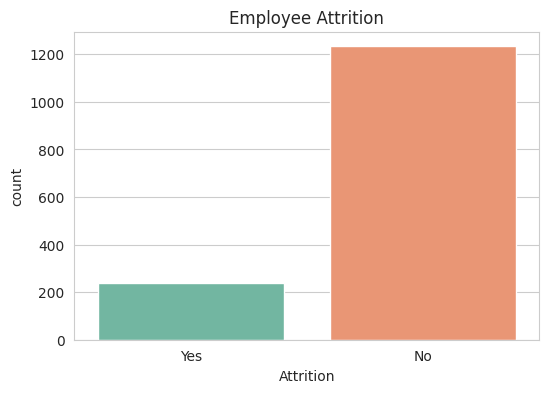

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Attrition',
    palette='Set2'
)

plt.title("Employee Attrition")
plt.show()

In [9]:
print("Total Employees :", len(df))
print("Average Age :", round(df['Age'].mean(),1))
print("Average Salary :", round(df['MonthlyIncome'].mean(),2))
print("Average Years at Company :", round(df['YearsAtCompany'].mean(),1))

Total Employees : 1470
Average Age : 36.9
Average Salary : 6502.93
Average Years at Company : 7.0


In [10]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [11]:
for col in cat_cols:
    print("\n")
    print(col)
    print(df[col].value_counts())



Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64


BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64


Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


Gender
Gender
Male      882
Female    588
Name: count, dtype: int64


JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


MaritalStatus
MaritalStatus
Married  

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

## Age Distribution
This visualization shows the age distribution of employees.

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

### Insight
- Most employees are between **30–40 years** old.
- The distribution is approximately normal.

## Gender Distribution

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x='Gender',palette='Set2')
plt.title('Gender Distribution')
plt.show()

## Department Distribution

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,y='Department',order=df['Department'].value_counts().index)
plt.title('Employees by Department')
plt.show()

## Job Role Distribution

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,y='JobRole',order=df['JobRole'].value_counts().index)
plt.title('Employees by Job Role')
plt.show()

## Monthly Income Distribution

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['MonthlyIncome'],bins=30,kde=True)
plt.title('Monthly Income Distribution')
plt.show()

## Attrition by Department

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='Department',hue='Attrition')
plt.xticks(rotation=20)
plt.title('Attrition by Department')
plt.show()

## Attrition by Gender

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x='Gender',hue='Attrition')
plt.title('Attrition by Gender')
plt.show()

## Attrition by Overtime

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(data=df,x='OverTime',hue='Attrition')
plt.title('Overtime vs Attrition')
plt.show()

## Correlation Heatmap

In [ ]:
plt.figure(figsize=(14,10))
corr=df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Conclusion
The exploratory analysis highlights key factors associated with employee attrition, including overtime, department, job role, income, and demographic characteristics. These insights can support HR decision-making and employee retention strategies.